In [ ]:
import os
import random
import collections
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.v2 as v2
import torchvision.transforms.functional as F
from torchvision.tv_tensors import Image, Mask
from tqdm import tqdm

In [ ]:
from google.colab import drive

# 드라이브 마운트
drive.mount('/content/drive')

# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

Mounted at /content/drive
cuda


1. 미션 소개
    - 이번 미션에서는 U-Net을 이용해 축구 경기 영상 내의 다양한 객체(예: 골대, 심판, 선수, 관중 등)를 픽셀 단위로 분할하는 Semantic Segmentation 작업을 수행합니다. 실제 경기 장면에서 추출한 이미지를 바탕으로, 각 픽셀이 어떤 클래스에 속하는지 예측하는 모델을 직접 설계하고 학습해보세요.

2. 데이터 소개
    - 데이터 링크: Football(Semantic Segmentation) (https://www.kaggle.com/datasets/sadhliroomyprime/football-semantic-segmentation/data)
    - 데이터 구성
        - 본 데이터셋은 UEFA 슈퍼컵 2017 레알 마드리드 vs 맨체스터 유나이티드 경기 하이라이트 영상을 기반으로 수집된 축구 경기 장면들로 구성되어 있습니다. 총 100장의 프레임을 사용하였으며, 매 12번째 프레임을 추출해 흐릿한 장면이나 이상치는 일부 대체했습니다.
        - 11개 클래스가 포함되어 있습니다.
            - Goal Bar (골대)
            - Referee (심판)
            - Advertisement (광고판)
            - Ground (잔디)
            - Ball (축구공)
            - Coaches & Officials (코칭 스태프 및 심판진)
            - Audience (관중)
            - Goalkeeper A (팀 A 골키퍼)
            - Goalkeeper B (팀 B 골키퍼)
            - Team A (팀 A 선수)
            - Team B (팀 B 선수)

3. 제출 안내
    - 다음 내용을 포함한 Colab Notebook 파일을 제출해 주세요.

    1. 분석 과정과 결과
        - 데이터 로드, 전처리, 모델 학습, 예측, 성능 평가 등의 과정을 진행해 주세요.
        - U-Net 모델을 사용해 픽셀 단위로 11개 클래스를 세분화해 주세요.
    2. 마크다운을 활용한 설명
        - 각 코드 셀이 수행하는 작업(의도, 알고리즘, 함수 설명 등)을 마크다운을 통해 자세히 기록해 주세요.
        - 노트북 내에서 코드와 결과를 한눈에 이해할 수 있도록 정리해 주세요.
    3. 모델 성능 평가 및 제출
        - Cross Entropy Loss, Dice Loss 등 Segmentation 분야에서 사용하는 평가 지표를 활용해 모델 성능을 평가해 보세요.
        - 데이터셋을 학습용과 테스트용으로 분할하여, 테스트 세트에서 모델을 평가한 결과를 노트북에 포함해 주세요. 최종 학습된 모델과 시각화 결과가 포함된 Notebook 파일을 제출해 주세요.

4. 참고 사항
    - 미션을 시작할 때 도움이 필요하다면, Baseline 코드를 참고할 수 있습니다. 이 코드는 기본적인 코드로 제공되며, 여러분이 원하는 대로 자유롭게 변형할 수 있어요.
        - Baseline 코드 링크
        - 주의 사항: Baseline 코드는 여러분이 모델을 시작하는 데 도움을 주기 위한 참고 자료일 뿐이며, Baseline 코드를 그대로 사용하는 것보다는 이를 기반으로 자신의 아이디어를 추가하고 발전시키는 것이 중요합니다. 가능하면 스스로 모델을 구축해보고 다양한 방법을 시도하여 성능을 향상시켜 보세요.
    - 모델 성능 개선해 보기
        - 데이터 증강(Data Augmentation): 축구 영상은 조명, 경기장 환경, 선수 유니폼 색상 등 변동이 많으므로, Random Crop, Horizontal Flip, Color Jitter 등의 증강 기법을 적용하면 모델의 일반화 성능이 향상될 수 있습니다.
        - 하이퍼파라미터 튜닝: 학습률, 배치 크기, 에폭 수 등 파라미터를 조정해 보며 최적값을 찾아보세요.
        - 모델 구조: 필요에 따라 U-Net++나 Attention U-Net과 같이 개선된 모델 구조를 적용해 보는 것도 좋은 방법입니다.

About Dataset(https://www.kaggle.com/datasets/sadhliroomyprime/football-semantic-segmentation/data)
DEDICATING THIS FULL SEMANTIC DATASET TO THE ONGOING FIFA 2022 IN QATAR.

The 100 frames are taken at every 12th frame (with some blurred frames and outliers replaced) from the match between Real Madrid and Manchester United from open media. The dataset is appropriate for training detection models in respect to sports analytics, of course biased towards soccer.

The source data was collected from the UEFA Super Cup match between Real Madrid and Manchester United in 2017 (Highlights).

11 standard classes are used which includes: Goal Bar, Referee, Advertisement, Ground, Ball, Coaches & Officials, Audience, Goalkeeper A, Goalkeeper B, Team A, and Team B.

We used SuperAnnotate’s pixel editor to label and classify the images following instance segmentation principles. Export was made in COCO with fused labels to optimise interoperability and visual understanding.

Dataset is created by Acme AI Ltd. (www.acmeai.tech) and is #openaccess

Summary
303 files

.json #1

.jpg #100

.png #200

Other #2

# 0.연구 방법 및 결론

0. Kaggle(https://www.kaggle.com/code/youngsunjoung/image-segmentation-of-football-pytorch)

1. 데이터
    1. 데이터 분할
        - Train Data: 80, Val Data: 10, Test Data: 10
        - image size: [5, 3, 256, 256]
        - mask size : [5, 256, 256]
    2. 데이터 증강
        - 증강을 적용한 것과 아닌 것, 두 개
        - 좌우 반전, 상하 반전, 10도 회전, 랜덤 크롭 이후 리사이징
2. 모델 정의
    1. 기본 : U-Net
        - (batch, 3, H, W) -> (batch, 1024, H/16, W/16) -> (batch, num_classes, H, W)
        - Conv Block : (3x3Conv, BN, ReLU) x 2
    2. Attention U-Net
        - (batch, 3, H, W) -> (batch, 1024, H/16, W/16) -> (batch, num_classes, H, W)
        - Attention Gate(Encoding -> Decoding)
        - Conv Block(Bottleneck) : (1x1Conv, BN, ReLU) -> (3x3Conv, BN, ReLU) -> (1x1Conv, BN, ReLU) -> Dropout(0.2) -> (1x1Conv, BN, ReLU) -> (3x3Conv, BN, ReLU) -> (1x1Conv, BN, ReLU)
    3. Backbone(resnet50)
        - smp.Unet(encoder_name="resnet50", encoder_weights="imagenet", in_channels=3, classes=11)
4. 학습방식
    - 에포크당 학습과 검증을 동시에 진행, 검증 손실이 줄어든 경우에만 모델을 저장
    - 학습된 모델을 불러와 시험 데이터에 적용 및 시각화
    - criterion : Hybrid Loss(Focal Loss * 0.5 + Dice Loss * 0.5)
    - optimizer : Adam w/ lr=0.005, weight_decay=1e-4
5. 모델 별 결과
    1. U-Net(증강 없음)
        - num_epochs=35, scheduler=CosineAnnealingLR w/ T_max=num_epochs, eta_min=1e-6
        - Saved at Epoch: 35, Best Metric: 0.2323 / Test Loss: 0.2089
        - 오히려 가장 빠른 시간 내에 성능이 줄어들었음
    2. U-Net(증강 있음)
        - num_epochs=51, ReduceLROnPlateau w/ mode='min', factor=0.5, patience=3, threshold=1e-4, min_lr=1e-6
        - Saved at Epoch: 51, Best Metric: 0.2488 / Test Loss: 0.2413
        - 증강이 없는 것과 비교해서 시험 손실 차이만큼 시각화의 차이가 있다.
    3. Attention U-Net(증강 있음)
        - num_epochs=40, scheduler=CosineAnnealingLR w/ T_max=num_epochs, eta_min=1e-6
        - Saved at Epoch: 40, Best Metric: 0.2658 / Test Loss: 0.2691
        - ReduceLROnPlateau는 너무 느리게 학습되어서 스케쥴러를 바꿨지만 효과는 없었다.
    4. Backbone w/ ResNet50(증강 있음)
        - num_epochs=50, ReduceLROnPlateau w/ mode='min', factor=0.5, patience=3, threshold=1e-4, min_lr=1e-6
        - Saved at Epoch: 49, Best Metric: 0.2494 / Test Loss: 0.2452
        - 사전 학습된 모델이었지만 큰 차이는 없었다.
5. 결론
    - 데이터의 숫자가 100개밖에 되지 않았기에 이런 결과가 나오지 않았나 싶다. 비슷한 결과를 캐글(https://www.kaggle.com/code/manuelnkegoum/u-net) 에서도 찾을 수 있었다. 이 글에서도 비슷하게 검증 손실이 0.2대에 머물러 있었다.
    - 그러나 Image Segmentation이라는 좋은 경험을 했다고 생각한다.

# 1.데이터 불러오기

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sadhliroomyprime/football-semantic-segmentation")

print("Path to dataset files:", path)

100%|██████████| 68.7M/68.7M [00:01<00:00, 64.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sadhliroomyprime/football-semantic-segmentation/versions/1


In [ ]:
import os
import collections

# 폴더 내부 이미지 모두 가져오기
image_folder = os.path.join(path, "images")
file_list = os.listdir(image_folder)

# 출력물 확인
print(f"file_list: {len(file_list)}")
print(file_list)

file_list: 300
['Frame 1  (60).jpg___save.png', 'Frame 1  (45).jpg___fuse.png', 'Frame 1  (98).jpg', 'Frame 1  (100).jpg___fuse.png', 'Frame 1  (12).jpg___save.png', 'Frame 1  (91).jpg___fuse.png', 'Frame 1  (59).jpg', 'Frame 1  (73).jpg___save.png', 'Frame 1  (56).jpg___save.png', 'Frame 1  (75).jpg___fuse.png', 'Frame 1  (78).jpg', 'Frame 1  (1).jpg___save.png', 'Frame 1  (89).jpg', 'Frame 1  (97).jpg___save.png', 'Frame 1  (51).jpg', 'Frame 1  (15).jpg___fuse.png', 'Frame 1  (50).jpg___fuse.png', 'Frame 1  (55).jpg', 'Frame 1  (44).jpg', 'Frame 1  (50).jpg', 'Frame 1  (99).jpg___save.png', 'Frame 1  (72).jpg___save.png', 'Frame 1  (95).jpg___fuse.png', 'Frame 1  (68).jpg___fuse.png', 'Frame 1  (21).jpg___fuse.png', 'Frame 1  (6).jpg___save.png', 'Frame 1  (93).jpg___save.png', 'Frame 1  (72).jpg___fuse.png', 'Frame 1  (58).jpg___fuse.png', 'Frame 1  (79).jpg', 'Frame 1  (91).jpg___save.png', 'Frame 1  (17).jpg___save.png', 'Frame 1  (28).jpg___save.png', 'Frame 1  (11).jpg___save.pn

In [ ]:
# 원본이미지와 fuse이미지, save이미지
original_images = sorted([f for f in file_list if f.endswith(".jpg")])
fuse_images = sorted([f for f in file_list if "fuse" in f])
save_images = sorted([f for f in file_list if "save" in f])

print(original_images)
print(fuse_images)
print(save_images)

['Frame 1  (1).jpg', 'Frame 1  (10).jpg', 'Frame 1  (100).jpg', 'Frame 1  (11).jpg', 'Frame 1  (12).jpg', 'Frame 1  (13).jpg', 'Frame 1  (14).jpg', 'Frame 1  (15).jpg', 'Frame 1  (16).jpg', 'Frame 1  (17).jpg', 'Frame 1  (18).jpg', 'Frame 1  (19).jpg', 'Frame 1  (2).jpg', 'Frame 1  (20).jpg', 'Frame 1  (21).jpg', 'Frame 1  (22).jpg', 'Frame 1  (23).jpg', 'Frame 1  (24).jpg', 'Frame 1  (25).jpg', 'Frame 1  (26).jpg', 'Frame 1  (27).jpg', 'Frame 1  (28).jpg', 'Frame 1  (29).jpg', 'Frame 1  (3).jpg', 'Frame 1  (30).jpg', 'Frame 1  (31).jpg', 'Frame 1  (32).jpg', 'Frame 1  (33).jpg', 'Frame 1  (34).jpg', 'Frame 1  (35).jpg', 'Frame 1  (36).jpg', 'Frame 1  (37).jpg', 'Frame 1  (38).jpg', 'Frame 1  (39).jpg', 'Frame 1  (4).jpg', 'Frame 1  (40).jpg', 'Frame 1  (41).jpg', 'Frame 1  (42).jpg', 'Frame 1  (43).jpg', 'Frame 1  (44).jpg', 'Frame 1  (45).jpg', 'Frame 1  (46).jpg', 'Frame 1  (47).jpg', 'Frame 1  (48).jpg', 'Frame 1  (49).jpg', 'Frame 1  (5).jpg', 'Frame 1  (50).jpg', 'Frame 1  (51).j

In [ ]:
# 사이즈 확인 (H, W, C)

def unique_sizes(image_files, image_folder):
    unique_sizes = set()

    for image in image_files:
        img_path = os.path.join(image_folder, image)
        img = cv2.imread(img_path)

        # 이미지 크기 확인
        height, width, channels = img.shape
        img_size = (height, width, channels)

        # 중복 건너뛰기
        if img_size in unique_sizes:
            continue

        # 새로운 크기만 출력
        print(f"Image Size (H, W, C): {height}, {width}, {channels}")
        unique_sizes.add(img_size)

print("Unique sizes of Original Image")
unique_sizes(original_images, image_folder)
print("Unique sizes of Fuse Image")
unique_sizes(fuse_images, image_folder)
print("Unique sizes of Save Image")
unique_sizes(save_images, image_folder)

Unique sizes of Original Image
Image Size (H, W, C): 1080, 1920, 3
Unique sizes of Fuse Image
Image Size (H, W, C): 1080, 1920, 3
Unique sizes of Save Image
Image Size (H, W, C): 1080, 1920, 3


1. 원본 이미지 : 원본 경기 장면(RGB 이미지)
    - (H, W, 3) 크기
    - 모델의 입력 이미지
2. fuse 이미지 : 원본 이미지 + GT 마스크 합성
    - 클래스 별로 특정 색상이 적용됨
    - 훈련 과정에서 모델이 학습한 내용과 Ground Truth를 비교하는 용도
    - 모델 학습 후 시각적으로 결과를 확인
3. save 이미지 : 문서 내부에 정보가 없으며 GT 마스크도 아님

## 1.1. 데이터 시각화

In [ ]:
import os
import cv2

# 이미지 페어링
image_pairs = []
for original_image in original_images:
    # 동일한 프레임의 fuse, save 파일 찾기
    base_name = original_image.replace(".jpg", "")
    fuse_image = next((f for f in fuse_images if base_name in f), None)
    save_image = next((f for f in save_images if base_name in f), None)

    if fuse_image and save_image:
        # 원본과 마스크 로드
        original_path = os.path.join(image_folder, original_image)
        fuse_path = os.path.join(image_folder, fuse_image)
        save_path = os.path.join(image_folder, save_image)

        orig = cv2.imread(original_path)
        fuse = cv2.imread(fuse_path)
        save = cv2.imread(save_path)

        if orig is not None and fuse is not None and save is not None:
            image_pairs.append((orig, fuse, save))

# 이미지 페어링 확인
print(f"{len(image_pairs)} pairs")

100 pairs


5 samples


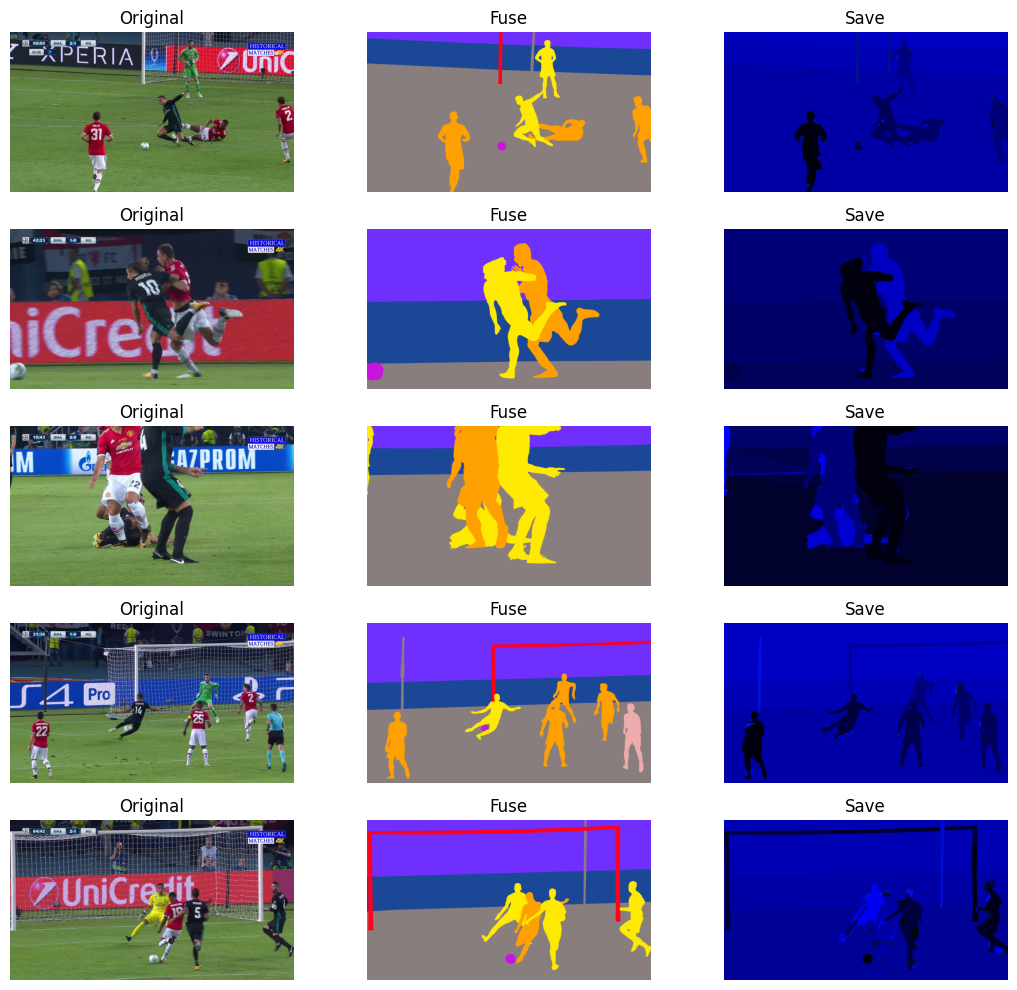

In [ ]:
import matplotlib.pyplot as plt
import random

# 이미지 페어링 시각화
num_samples = 5
sample_image_pairs = random.sample(image_pairs, num_samples)

# 샘플 개수 확인
print(f"{len(sample_image_pairs)} samples")

# 시각화
fig, axes, = plt.subplots(num_samples, 3, figsize=(11, 10))

for i, (orig, fuse, save) in enumerate(sample_image_pairs):
    # 원본 이미지
    axes[i, 0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    # fuse
    axes[i, 1].imshow(cv2.cvtColor(fuse, cv2.COLOR_BGR2RGB))
    axes[i, 1].set_title("Fuse")
    axes[i, 1].axis("off")

    # save
    axes[i, 2].imshow(cv2.cvtColor(save, cv2.COLOR_BGR2RGB))
    axes[i, 2].set_title("Save")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

Save 이미지가 무엇인지는 가늠이 안된다.
따라서 Original 이미지와 Fuse 이미지를 갖고서 학습을 진행하겠다.

## 1.2. 마스크 라벨링

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

# 데이터셋 전체의 고유 색상 수집
def get_unique_colors(image_folder, mask_files, max_classes=11):
    """
    데이터셋의 모든 마스크에서 고유한 색상을 추출하는 함수.

    Args:
        image_folder (str): 마스크 이미지가 있는 폴더 경로
        mask_files (list): 마스크 이미지 파일 리스트
        max_classes (int): 최대 클래스 개수 (기본값: 11)

    Returns:
        list: 고유한 색상 리스트 (최대 max_classes개)
    """
    color_set = set()

    for mask_file in mask_files:
        mask_path = os.path.join(image_folder, mask_file)
        mask = cv2.imread(mask_path, cv2.IMREAD_COLOR)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        unique_colors, _ = np.unique(mask.reshape(-1, 3), axis=0, return_counts=True)   # 고유한 색상 추출 (H * W, 3)

        for color in unique_colors:
            if tuple(color) not in color_set:   # 새로운 색상만 추가
                color_set.add(tuple(color))

                # 클래스 개수가 max_classes를 넘으면 중단
                if len(color_set) >= max_classes:
                    return list(color_set)

    return list(color_set)

# 모든 마스크에서 등장하는 색상 수집
unique_colors = get_unique_colors(image_folder, fuse_images)
print(f"Unique colors: {len(unique_colors)}")

Unique colors: 11


In [ ]:
color_to_label = {color: idx for idx, color in enumerate(unique_colors)}
print(color_to_label)

{(238, 171, 171): 0, (254, 233, 3): 1, (0, 0, 0): 2, (255, 0, 29): 3, (111, 48, 253): 4, (137, 126, 126): 5, (27, 71, 151): 6, (255, 160, 1): 7, (201, 19, 223): 8, (255, 159, 0): 9, (255, 235, 0): 10}


## 1.3. 데이터셋

In [ ]:
# 데이터셋 클래스 정의
class FootballDataset(Dataset):
    def __init__(self, image_files, mask_files, image_folder, color_to_label, transform=None):
        self.image_files = image_files
        self.mask_files = mask_files
        self.image_folder = image_folder
        self.color_to_label = color_to_label  # 고정된 클래스 매핑
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_folder, self.image_files[idx])
        mask_path = os.path.join(self.image_folder, self.mask_files[idx])

        # 원본 이미지 로드
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 마스크 로드 (RGB 모드)
        mask = cv2.imread(mask_path, cv2.IMREAD_COLOR)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

        # 트랜스폼 분기
        if self.transform is None:
            img = cv2.resize(img, (256, 256)) / 255.0  # 정규화
            img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)  # (H, W, C) → (C, H, W)

            mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
            mask = torch.tensor(mask, dtype=torch.uint8).permute(2, 0, 1)  # (H, W, C) → (C, H, W)
        else:
            # tv_tensor 사용
            img = Image(torch.from_numpy(img).permute(2, 0, 1))  # (H, W, C) → (C, H, W)
            mask = Mask(torch.from_numpy(mask).permute(2, 0, 1))  # (H, W, C) → (C, H, W)
            img, mask = self.transform(img, mask)

        # 고정된 color_to_label을 사용하여 클래스 변환
        mask_np = mask.permute(1, 2, 0).numpy()
        mask_class = np.zeros(mask_np.shape[:2], dtype=np.uint8)
        for color, label in self.color_to_label.items():
            mask_class[np.all(mask_np == np.array(color), axis=-1)] = label  # 고정된 ID 사용

        # 최종 마스크 변환
        mask = torch.tensor(mask_class, dtype=torch.long)  # (H, W)

        return img, mask

In [ ]:
from torch.utils.data import random_split, DataLoader

# 전체 데이터셋 크기
dataset_size = len(original_images)
trainval_size = int(0.9 * dataset_size)  # 90 Train
test_size = dataset_size - trainval_size  # 10 Test

# 이미지와 마스크를 (img, mask) 튜플로 묶음
paired_files = list(zip(original_images, fuse_images))

# 랜덤하게 trainval/test 분할
trainval_files, test_files = random_split(paired_files, [trainval_size, test_size])

# 랜덤하게 train/val 분할
val_size = int(1/9 * trainval_size)  # 10 Validation
train_size = trainval_size - val_size  # 80 Train
train_files, val_files = random_split(trainval_files, [train_size, val_size])


# 분할된 데이터셋에서 이미지/마스크 파일 분리
train_image_files, train_mask_files = zip(*train_files)
val_image_files, val_mask_files = zip(*val_files)
test_image_files, test_mask_files = zip(*test_files)

# 출력물 매칭 확인
print("Checking Train images and masks")
for img, mask in zip(train_image_files, train_mask_files):
    base_img = img.split(".jpg")[0]
    base_mask = mask.split(".jpg___fuse.png")[0]
    if base_img != base_mask:
        print(f"Mismatch: {img} <-> {mask}")

print("Checking Val images and masks")
for img, mask in zip(val_image_files, val_mask_files):
    base_img = img.split(".jpg")[0]
    base_mask = mask.split(".jpg___fuse.png")[0]
    if base_img != base_mask:
        print(f"Mismatch: {img} <-> {mask}")

print("Checking Test images and masks")
for img, mask in zip(test_image_files, test_mask_files):
    base_img = img.split(".jpg")[0]
    base_mask = mask.split(".jpg___fuse.png")[0]
    if base_img != base_mask:
        print(f"Mismatch: {img} <-> {mask}")

Checking Train images and masks
Checking Val images and masks
Checking Test images and masks


### 1.3.1. 증강이 없는 데이터셋

In [ ]:
# 데이터셋
train_dataset = FootballDataset(train_image_files, train_mask_files, image_folder, color_to_label)
val_dataset = FootballDataset(val_image_files, val_mask_files, image_folder, color_to_label)
test_dataset = FootballDataset(test_image_files, test_mask_files, image_folder, color_to_label)

# 80, 10, 10이므로 배치사이즈를 5로 조정
train_loader = DataLoader(train_dataset, batch_size=5, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=5, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=False)

print(f"Train Data: {len(train_dataset)}, Val Data: {len(val_dataset)}, Test Data: {len(test_dataset)}")

for img, mask in train_loader:
    print(f"image size: {img.shape}")
    print(f"mask size: {mask.shape}")
    break

Train Data: 80, Val Data: 10, Test Data: 10
image size: torch.Size([5, 3, 256, 256])
mask size: torch.Size([5, 256, 256])


### 1.3.2. 증강이 있는 데이터셋

In [ ]:
# 트랜스폼 설정
train_transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),  # 좌우 반전
    v2.RandomVerticalFlip(p=0.2),  # 상하 반전
    v2.RandomRotation(degrees=10),  # ±10도 회전
    v2.RandomResizedCrop(size=(256, 256), scale=(0.8, 1.0)),  # 랜덤 크롭 후 리사이징
    v2.ToDtype(torch.float32, scale=True),
])

valtest_transform = v2.Compose([
    v2.Resize((256, 256)),  # 크기만 조정
    v2.ToDtype(torch.float32, scale=True),
])

In [ ]:
# 증강된 데이터셋
train_transformed_dataset = FootballDataset(train_image_files, train_mask_files, image_folder, color_to_label, train_transform)
val_transformedtrain_transformed_dataset = FootballDataset(val_image_files, val_mask_files, image_folder, color_to_label, valtest_transform)
test_transformedtrain_transformed_dataset = FootballDataset(test_image_files, test_mask_files, image_folder, color_to_label, valtest_transform)

# 80, 10, 10이므로 배치사이즈를 5로 조정
train_transformed_loader = DataLoader(train_transformed_dataset, batch_size=5, shuffle=True, drop_last=False)
val_transformed_loader = DataLoader(val_transformedtrain_transformed_dataset, batch_size=5, shuffle=False, drop_last=False)
test_transformed_loader = DataLoader(test_transformedtrain_transformed_dataset, batch_size=1, shuffle=False, drop_last=False)

print(f"Train Data: {len(train_transformed_dataset)}, Val Data: {len(val_transformedtrain_transformed_dataset)}, Test Data: {len(test_transformedtrain_transformed_dataset)}")

for img, mask in train_transformed_loader:
    print(f"image size: {img.shape}")
    print(f"mask size: {mask.shape}")
    break

Train Data: 80, Val Data: 10, Test Data: 10
image size: torch.Size([5, 3, 256, 256])
mask size: torch.Size([5, 256, 256])


#### 1.3.2.1. 증강 시각화

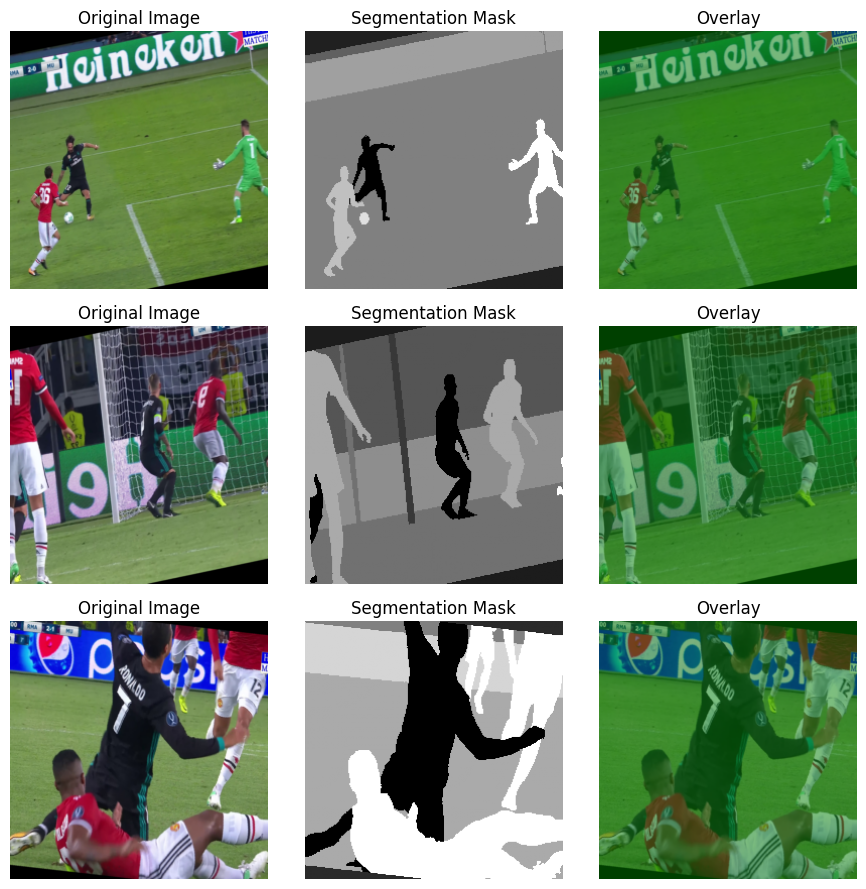

In [ ]:
import matplotlib.pyplot as plt
import torchvision.transforms.v2.functional as F
from torchvision.utils import draw_segmentation_masks

def visualize_samples(loader, num_samples=3):
    """ 데이터 로더에서 샘플을 가져와 이미지, 마스크, 오버레이 확인하는 함수 """
    data_iter = iter(loader)
    imgs, masks = next(data_iter)  # 배치에서 첫 번째 샘플 가져오기

    fig, axs = plt.subplots(num_samples, 3, figsize=(9, num_samples * 3))  # (num_samples, 3) 크기의 서브플롯

    for i in range(num_samples):
        img = imgs[i]
        mask = masks[i]

        # 이미지를 0~1 범위로 변환 (tv_tensors.Image는 일반적으로 정규화되어 있음)
        img = F.to_dtype(img, torch.uint8, scale=True)

        # 마스크를 Boolean Mask로 변환하여 시각화
        mask_overlay = draw_segmentation_masks(img, mask.unsqueeze(0).to(torch.bool), colors=["green"], alpha=0.5)

        # 원본 이미지 출력
        axs[i, 0].imshow(img.permute(1, 2, 0).numpy())  # (C, H, W) → (H, W, C)
        axs[i, 0].set_title("Original Image")
        axs[i, 0].axis("off")

        # 마스크 출력 (Grayscale 변환)
        axs[i, 1].imshow(mask.numpy(), cmap="gray")
        axs[i, 1].set_title("Segmentation Mask")
        axs[i, 1].axis("off")

        # 오버레이된 이미지 출력
        axs[i, 2].imshow(mask_overlay.permute(1, 2, 0).numpy())  # (C, H, W) → (H, W, C)
        axs[i, 2].set_title("Overlay")
        axs[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

# 학습 데이터 트랜스폼 적용 확인
visualize_samples(train_transformed_loader)

In [ ]:
# 데이터셋 샘플을 가져와 확인
for img, mask in train_transformed_loader:
    print(f"Image shape: {img.shape}")  # (5, 3, 256, 256)
    print(f"Mask shape: {mask.shape}")  # (5, 256, 256)

    # 이미지 값 범위 확인
    print(f"Image min: {img.min()}, max: {img.max()}")  # 0~1

    # 마스크 클래스 ID 확인
    print(f"Unique mask values: {torch.unique(mask)}")  # 0~10

    break  # 한 배치만 확인

Image shape: torch.Size([5, 3, 256, 256])
Mask shape: torch.Size([5, 256, 256])
Image min: 0.0, max: 1.0
Unique mask values: tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])


# 2.모델 저장 및 불러오기

In [ ]:
# 환경설정
if "COLAB_GPU" in os.environ:
    model_dir = "/content/drive/My Drive/model_storage/"
elif os.path.exists("/kaggle"):
    model_dir = "/kaggle/working/model_storage/"
else:
    model_dir = "./model_storage"


# 디렉토리 설정
os.makedirs(model_dir, exist_ok=True)
print(f"Now using Model Directory: {model_dir}")


# 모델 경로 확인하기
def get_model_path(model_name):
    return os.path.join(model_dir, f"{model_name}.pth")


# 모델 저장하기
def save_model(model, model_name, optimizer, scheduler, epoch, best_metric):
    model_path = get_model_path(model_name)
    checkpoint = {
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "epoch": epoch + 1,
        "best_metric": best_metric
    }
    torch.save(checkpoint, model_path)
    print(f"Checkpint Saved: {model_path}, Epoch: {epoch + 1}, Best Metric: {best_metric:.4f}")


# 모델 불러오기
def load_model(model, model_name, optimizer, scheduler):
    """
    return: model.to(device), epoch, best_metrich
    """
    model_path = get_model_path(model_name)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 모델 패스가 없으면 새로 시작
    if not os.path.exists(model_path):
        print(f"No Checkpoint Found: {model_path}")
        return model.to(device), 0, float("inf")

    # 모델 불러오기
    checkpoint = torch.load(model_path, map_location=device, weights_only=True)

    model.load_state_dict(checkpoint["model"])
    epoch = checkpoint["epoch"]
    best_metric = checkpoint["best_metric"]

    # 평가시에는 optimizer, scheduler 부르지 않음
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint["optimizer"])
    if scheduler is not None:
        scheduler.load_state_dict(checkpoint["scheduler"])

    print(f"Checkpoint Loaded: {model_path}, Epoch: {epoch}, Best Metric: {best_metric:.4f}")
    return model.to(device), epoch, best_metric


# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

Now using Model Directory: /content/drive/My Drive/model_storage/
cuda


# 3.모델 학습 및 평가

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary

In [ ]:
# 학습 및 검증 함수
def train_model(model, model_name, trainloader, valloader, criterion, optimizer, scheduler, num_epochs):
    model.to(device)
    model, start_epoch, best_metric = load_model(model, model_name, optimizer, scheduler)

    print(f"Start with Epoch={start_epoch}, Best Metric={best_metric}")
    for epoch in range(start_epoch, num_epochs):
        # 학습 시작
        model.train()
        train_loss = 0
        avg_train_loss = 0

        # 학습 진행
        train_bar = tqdm(trainloader, desc=f"Training {epoch+1}/{num_epochs}")
        for images, masks in train_bar:
            images, masks = images.to(device), masks.to(device)
            masks = torch.clamp(masks, min=0, max=10) # 0~10 범위 유지

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_bar.set_postfix({"Loss": loss.item()})

        avg_train_loss = train_loss / len(trainloader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_train_loss:.4f}")

        # 검증 시작
        model.eval()
        val_loss = 0
        avg_val_loss = 0
        val_bar = tqdm(valloader, desc=f"Validation {epoch+1}/{num_epochs}")

        with torch.no_grad():
            for images, masks in val_bar:
                images, masks = images.to(device), masks.to(device)
                masks = torch.clamp(masks, min=0, max=10) # 0~10 범위

                outputs = model(images)
                loss = criterion(outputs, masks)

                val_loss += loss.item()
                val_bar.set_postfix({"Loss": loss.item()})

        avg_val_loss = val_loss / len(valloader)
        print(f"Validation Loss: {avg_val_loss:.4f}\n")

        # 스케쥴러 체크
        if scheduler is not None:
            current_lr = optimizer.param_groups[0]['lr']
            # ReduceLROnPlateau 예외
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(avg_val_loss)
            else:
                scheduler.step()
            updated_lr = optimizer.param_groups[0]['lr']
            if updated_lr != current_lr:
                print(f"Learning Rate Updated: {current_lr:6f} -> {updated_lr:6f}")

        # 검증손실이 개선되면 저장
        if avg_val_loss < best_metric:
            print(f"Best Validation Metric Updated: {best_metric:.4f} -> {avg_val_loss:.4f}")
            best_metric = avg_val_loss
            save_model(model, model_name, optimizer, scheduler, epoch, best_metric)

1. Focal Loss
    - Cross Entropy Loss의 개선된 버전
    - 클래스 불균형 문제 해결을 위해 도입
    - 쉽게 맞추는 샘플보다 어려운 샘플에 더 큰 가중치를 부여하여 모델이 어려운 샘플을 더 학습하도록 유도

2. Dice Loss
    - 불균형한 데이터에서 주로 사용되는 Segmentation Loss
    - IoU(Intersection over Union)와 유사한 방식으로 픽셀 간 유사성을 극대화
    - 작은 객체나 적은 픽셀 개수를 가진 클래스를 보다 잘 학습할 수 있도록 함

3. Hybrid Loss(Focal Loss + Dice Loss)
    - 두 가지 손실을 50:50 비율로 결합하여 균형 잡힌 학습을 유도해보겠다.

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce_loss = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6, num_classes=11):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
        self.num_classes = num_classes  # 클래스 개수 설정

    def forward(self, inputs, targets):
        # Logits → 확률 변환 (softmax)
        inputs = torch.softmax(inputs, dim=1)

        # targets를 One-Hot Encoding 변환 (batch_size, height, width) → (batch_size, num_classes, height, width)
        targets = torch.nn.functional.one_hot(targets, num_classes=self.num_classes).permute(0, 3, 1, 2).float()

        # Dice Loss 계산
        intersection = (inputs * targets).sum(dim=(2, 3))  # 각 클래스별 교집합
        dice_score = (2. * intersection + self.smooth) / (inputs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + self.smooth)
        return 1 - dice_score.mean()  # Dice Score를 Loss로 변환


class HybridLoss(nn.Module):
    def __init__(self, alpha=0.5, num_classes=11):
        super(HybridLoss, self).__init__()
        self.focal = FocalLoss()
        self.dice = DiceLoss(num_classes=num_classes)
        self.alpha = alpha  # Focal Loss 가중치

    def forward(self, inputs, targets):
        return self.alpha * self.focal(inputs, targets) + (1 - self.alpha) * self.dice(inputs, targets)

## 3.1. Baseline UNet

In [ ]:
# U-Net 모델 정의 (BatchNorm 추가)
class UNet(nn.Module):
    def __init__(self, num_classes=11):
        super(UNet, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),  # BatchNorm 추가
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),  # BatchNorm 추가
                nn.ReLU(inplace=True),
            )

        self.encoder1 = conv_block(3, 64)
        self.encoder2 = conv_block(64, 128)
        self.encoder3 = conv_block(128, 256)
        self.encoder4 = conv_block(256, 512)

        self.pool = nn.MaxPool2d(2, 2)

        self.bottleneck = conv_block(512, 1024)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.decoder4 = conv_block(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.decoder3 = conv_block(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder2 = conv_block(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder1 = conv_block(128, 64)

        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # 인코딩
        e1 = self.encoder1(x)               # (batch, 64, H, W)
        e2 = self.encoder2(self.pool(e1))   # (batch, 128, H/2, W/2)
        e3 = self.encoder3(self.pool(e2))   # (batch, 256, H/4, W/4)
        e4 = self.encoder4(self.pool(e3))   # (batch, 512, H/8, W/8)

        # 보틀넥
        b = self.bottleneck(self.pool(e4))  # (batch, 1024, H/16, W/16)

        # 디코딩
        d4 = self.upconv4(b)                # (batch, 512, H/8, W/8)
        d4 = torch.cat((d4, e4), dim=1)     # (batch, 1024, H/8, W/8)
        d4 = self.decoder4(d4)              # (batch, 512, H/8, W/8)

        d3 = self.upconv3(d4)               # (batch, 256, H/4, W/4)
        d3 = torch.cat((d3, e3), dim=1)     # (batch, 512, H/4, W/4)
        d3 = self.decoder3(d3)              # (batch, 256, H/4, W/4)

        d2 = self.upconv2(d3)               # (batch, 128, H/2, W/2)
        d2 = torch.cat((d2, e2), dim=1)     # (batch, 256, H/2, W/2)
        d2 = self.decoder2(d2)              # (batch, 128, H/2, W/2)

        d1 = self.upconv1(d2)               # (batch, 64, H, W)
        d1 = torch.cat((d1, e1), dim=1)     # (batch, 128, H, W)
        d1 = self.decoder1(d1)              # (batch, 64, H, W)

        return self.final_conv(d1)          # (batch, num_classes, H, W)

In [ ]:
# 모델 학습
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(num_classes=11).to(device)

num_epochs = 35
criterion = HybridLoss(alpha=0.5, num_classes=11)
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

train_model(model, "Baseline_UNet", train_loader, val_loader, criterion, optimizer, scheduler, num_epochs)

No Checkpoint Found: /content/drive/My Drive/model_storage/Baseline_UNet.pth
Start with Epoch=0, Best Metric=inf


Training 1/35: 100%|██████████| 16/16 [00:08<00:00,  1.81it/s, Loss=0.432]


Epoch [1/35], Loss: 0.5046
Learning Rate Updated: 0.005000 -> 0.004990


Validation 1/35: 100%|██████████| 2/2 [00:00<00:00,  3.29it/s, Loss=0.437]


Validation Loss: 0.4350

Best Validation Metric Updated: inf -> 0.4350
Checkpint Saved: /content/drive/My Drive/model_storage/Baseline_UNet.pth, Epoch: 1, Best Metric: 0.4350


...

Validation Loss: 0.2325

Best Validation Metric Updated: 0.2329 -> 0.2325
Checkpint Saved: /content/drive/My Drive/model_storage/Baseline_UNet.pth, Epoch: 34, Best Metric: 0.2325


Training 35/35: 100%|██████████| 16/16 [00:08<00:00,  1.90it/s, Loss=0.237]


Epoch [35/35], Loss: 0.2251
Learning Rate Updated: 0.000011 -> 0.000001


Validation 35/35: 100%|██████████| 2/2 [00:00<00:00,  2.53it/s, Loss=0.244]


Validation Loss: 0.2323

Best Validation Metric Updated: 0.2325 -> 0.2323
Checkpint Saved: /content/drive/My Drive/model_storage/Baseline_UNet.pth, Epoch: 35, Best Metric: 0.2323


In [ ]:
# 고정된 컬러맵 설정 (GT & 예측 마스크 동일하게 적용)
fixed_colors = list(mcolors.TABLEAU_COLORS.values())  # "tab10" 컬러 10개 활용
label_colors = {label: fixed_colors[i % len(fixed_colors)] for i, label in enumerate(range(11))}  # 0~10 클래스
cmap_fixed = mcolors.ListedColormap([label_colors[label] for label in sorted(label_colors.keys())])

# 모델 로드 및 예측
model, _, _ = load_model(model, "Baseline_UNet", optimizer, scheduler)

with torch.no_grad():
    test_iter = iter(test_loader)
    plt.figure(figsize=(15, 40))

    plot_index = 1
    test_loss = 0
    for images, masks in test_iter:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)
        test_loss += loss.item()
        pred_masks = torch.argmax(torch.softmax(outputs, dim=1), dim=1).cpu().numpy()

        for b in range(images.size(0)):
            # 원본 이미지 출력
            plt.subplot(10, 3, plot_index)
            plt.imshow(images[b].cpu().permute(1, 2, 0))
            plt.title("Original Image")
            plt.axis("off")
            plot_index += 1

            # Ground Truth Mask 출력 (고정된 컬러맵 적용)
            plt.subplot(10, 3, plot_index)
            plt.imshow(masks[b].cpu().numpy(), cmap=cmap_fixed, vmin=0, vmax=10)
            plt.title("Ground Truth Mask")
            plt.axis("off")
            plot_index += 1

            # Predicted Mask 출력 (고정된 컬러맵 적용)
            plt.subplot(10, 3, plot_index)
            plt.imshow(pred_masks[b], cmap=cmap_fixed, vmin=0, vmax=10)
            plt.title("Predicted Mask")
            plt.axis("off")
            plot_index += 1

            if plot_index > 10 * 3:  # 10개 이미지까지 시각화
                break
        if plot_index > 10 * 3:
            break

    avg_test_loss = test_loss / len(test_loader)
    print(f"Test Loss: {avg_test_loss}")

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

CrossEntropyLoss에서 Focal Loss와 Dice Loss를 합친 Hybrid Loss로 바꾸니 경계가 명확히 살아났다. 로스가 0.2대인 것은 변함이 없지만 보기에는 훨씬 나아졌다.

## 3.2. Transformed Data

In [ ]:
# 모델 학습
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(num_classes=11).to(device)

num_epochs = 51
criterion = HybridLoss(alpha=0.5, num_classes=11)
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, threshold=1e-4, min_lr=1e-6)

train_model(model, "Transformed_UNet", train_transformed_loader, val_transformed_loader, criterion, optimizer, scheduler, num_epochs)

Checkpoint Loaded: /content/drive/My Drive/model_storage/Transformed_UNet.pth, Epoch: 50, Best Metric: 0.2503
Start with Epoch=50, Best Metric=0.2502709850668907


Training 51/51: 100%|██████████| 16/16 [00:19<00:00,  1.25s/it, Loss=0.187]


Epoch [51/51], Loss: 0.1964


Validation 51/51: 100%|██████████| 2/2 [00:00<00:00,  2.48it/s, Loss=0.248]


Validation Loss: 0.2488

Best Validation Metric Updated: 0.2503 -> 0.2488
Checkpint Saved: /content/drive/My Drive/model_storage/Transformed_UNet.pth, Epoch: 51, Best Metric: 0.2488


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import torch

# 고정된 컬러맵 설정 (GT & 예측 마스크 동일하게 적용)
fixed_colors = list(mcolors.TABLEAU_COLORS.values())  # "tab10" 컬러 10개 활용
label_colors = {label: fixed_colors[i % len(fixed_colors)] for i, label in enumerate(range(11))}  # 0~10 클래스
cmap_fixed = mcolors.ListedColormap([label_colors[label] for label in sorted(label_colors.keys())])

# 모델 로드 및 예측
model, _, _ = load_model(model, "Transformed_UNet", optimizer, scheduler)

with torch.no_grad():
    test_transformed_iter = iter(test_transformed_loader)
    plt.figure(figsize=(15, 40))

    plot_index = 1
    test_transformed_loss = 0
    for images, masks in test_transformed_iter:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)
        test_transformed_loss += loss.item()

        # 예측 마스크 변환 (argmax 적용)
        pred_masks = torch.argmax(torch.softmax(outputs, dim=1), dim=1).cpu().numpy()

        for b in range(images.size(0)):
            # 원본 이미지 출력
            plt.subplot(10, 3, plot_index)
            plt.imshow(images[b].cpu().permute(1, 2, 0).numpy())  # 그대로 출력 가능
            plt.title("Original Image")
            plt.axis("off")
            plot_index += 1

            # Ground Truth Mask 출력 (고정된 컬러맵 적용)
            plt.subplot(10, 3, plot_index)
            plt.imshow(masks[b].cpu().numpy(), cmap=cmap_fixed, vmin=0, vmax=10)
            plt.title("Ground Truth Mask")
            plt.axis("off")
            plot_index += 1

            # Predicted Mask 출력 (고정된 컬러맵 적용)
            plt.subplot(10, 3, plot_index)
            plt.imshow(pred_masks[b], cmap=cmap_fixed, vmin=0, vmax=10)
            plt.title("Predicted Mask")
            plt.axis("off")
            plot_index += 1

            if plot_index > 10 * 3:  # 10개 이미지까지 시각화
                break
        if plot_index > 10 * 3:
            break

    avg_test_transformed_loss = test_transformed_loss / len(test_transformed_loader)
    print(f"Test Loss: {avg_test_transformed_loss}")

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

증강된 데이터로 학습을 진행했을 때에는 ReduceLROnPlateau 스케쥴러를 사용했다.
학습은 느린 속도로 진행됐고, 이미지 시각화를 보면 경계선도 많이 흐린 것을 알 수 있다.
더 학습해보면 경계선이 분명해질 수 있다고 생각하지만 50번의 훈련으로 마친다.

## 3.3. Attention U-Net

In [ ]:
import torch.nn as nn
import torch.nn.functional as Func

# Attention Gate
class AttentionGate(nn.Module):
    def __init__(self, in_channels, gating_channels):
        super(AttentionGate, self).__init__()

        inter_channels = in_channels // 2

        self.W_x = nn.Sequential(
            nn.Conv2d(in_channels, inter_channels, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(inter_channels)
        )

        self.W_g = nn.Sequential(
            nn.Conv2d(gating_channels, inter_channels, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(inter_channels)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(inter_channels, 1, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

    def forward(self, x, g):
        # 크기 보정 (디코딩 전단계를 인코딩에 적용하므로 사이즈 보정이 필수적이다.)
        g = Func.interpolate(g, size=(x.shape[2:]), mode='bilinear', align_corners=True)

        x1 = self.W_x(x)
        g1 = self.W_g(g)

        psi = Func.relu(x1 + g1)
        psi = self.psi(psi)

        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self, num_classes=11):
        super(AttentionUNet, self).__init__()

        def bottleneck_conv_block(in_channels, out_channels):
            return nn.Sequential(
                # 첫 번째
                nn.Conv2d(in_channels, out_channels // 4, kernel_size=1, padding=0),
                nn.BatchNorm2d(out_channels // 4),
                nn.ReLU(inplace=True),

                nn.Conv2d(out_channels // 4, out_channels // 4, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels // 4),
                nn.ReLU(inplace=True),

                nn.Conv2d(out_channels // 4, out_channels, kernel_size=1, padding=0),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),

                # 드랍아웃
                nn.Dropout(0.2),

                # 두 번째
                nn.Conv2d(out_channels, out_channels // 4, kernel_size=1, padding=0),
                nn.BatchNorm2d(out_channels // 4),
                nn.ReLU(inplace=True),

                nn.Conv2d(out_channels // 4, out_channels // 4, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels // 4),
                nn.ReLU(inplace=True),

                nn.Conv2d(out_channels // 4, out_channels, kernel_size=1, padding=0),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            )

        # 인코딩
        self.encoder1 = bottleneck_conv_block(3, 64)
        self.encoder2 = bottleneck_conv_block(64, 128)
        self.encoder3 = bottleneck_conv_block(128, 256)
        self.encoder4 = bottleneck_conv_block(256, 512)

        self.pool = nn.MaxPool2d(2, 2)

        self.bottleneck = bottleneck_conv_block(512, 1024)

        # 디코딩
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.attn4 = AttentionGate(512, 1024)
        self.decoder4 = bottleneck_conv_block(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.attn3 = AttentionGate(256, 512)
        self.decoder3 = bottleneck_conv_block(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.attn2 = AttentionGate(128, 256)
        self.decoder2 = bottleneck_conv_block(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.attn1 = AttentionGate(64, 128)
        self.decoder1 = bottleneck_conv_block(128, 64)

        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)


    def forward(self, x):
        # 인코딩
        e1 = self.encoder1(x)               # (batch, 64, H, W)
        e2 = self.encoder2(self.pool(e1))   # (batch, 128, H/2, W/2)
        e3 = self.encoder3(self.pool(e2))   # (batch, 256, H/4, W/4)
        e4 = self.encoder4(self.pool(e3))   # (batch, 512, H/8, W/8)

        # 보틀넥
        b = self.bottleneck(self.pool(e4))  # (batch, 1024, H/16, W/16)

        # 디코딩
        d4 = self.upconv4(b)                # (batch, 512, H/8, W/8)
        e4 = self.attn4(e4, b)              # (batch, 512, H/8, W/8)
        d4 = torch.cat((d4, e4), dim=1)     # (batch, 1024, H/8, W/8)
        d4 = self.decoder4(d4)              # (batch, 512, H/8, W/8)

        d3 = self.upconv3(d4)               # (batch, 256, H/4, W/4)
        e3 = self.attn3(e3, d4)             # (batch, 256, H/4, W/4)
        d3 = torch.cat((d3, e3), dim=1)     # (batch, 512, H/4, W/4)
        d3 = self.decoder3(d3)              # (batch, 256, H/4, W/4)

        d2 = self.upconv2(d3)               # (batch, 128, H/2, W/2)
        e2 = self.attn2(e2, d3)             # (batch, 128, H/2, W/2)
        d2 = torch.cat((d2, e2), dim=1)     # (batch, 256, H/2, W/2)
        d2 = self.decoder2(d2)              # (batch, 128, H/2, W/2)

        d1 = self.upconv1(d2)               # (batch, 64, H, W)
        e1 = self.attn1(e1, d2)             # (batch, 64, H, W)
        d1 = torch.cat((d1, e1), dim=1)     # (batch, 128, H/2, W/2)
        d1 = self.decoder1(d1)              # (batch, 64, H, W)

        return self.final_conv(d1)          # (batch, num_classes, H, W)

In [ ]:
summary(AttentionUNet(num_classes=11), input_size=(8, 3, 256, 256))

Layer (type:depth-idx)                   Output Shape              Param #
AttentionUNet                            [8, 11, 256, 256]         --
├─Sequential: 1-1                        [8, 64, 256, 256]         --
│    └─Conv2d: 2-1                       [8, 16, 256, 256]         64
│    └─BatchNorm2d: 2-2                  [8, 16, 256, 256]         32
│    └─ReLU: 2-3                         [8, 16, 256, 256]         --
│    └─Conv2d: 2-4                       [8, 16, 256, 256]         2,320
│    └─BatchNorm2d: 2-5                  [8, 16, 256, 256]         32
│    └─ReLU: 2-6                         [8, 16, 256, 256]         --
│    └─Conv2d: 2-7                       [8, 64, 256, 256]         1,088
│    └─BatchNorm2d: 2-8                  [8, 64, 256, 256]         128
│    └─ReLU: 2-9                         [8, 64, 256, 256]         --
│    └─Dropout: 2-10                     [8, 64, 256, 256]         --
│    └─Conv2d: 2-11                      [8, 16, 256, 256]         1,040
│    

In [ ]:
# 모델 학습
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
attention_model = AttentionUNet(num_classes=11).to(device)

num_epochs = 40
criterion = HybridLoss(alpha=0.5, num_classes=11)
optimizer = optim.Adam(attention_model.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

train_model(attention_model, "AttentionUNet", train_transformed_loader, val_transformed_loader, criterion, optimizer, scheduler, num_epochs)

No Checkpoint Found: /content/drive/My Drive/model_storage/AttentionUNet.pth
Start with Epoch=0, Best Metric=inf


Training 1/40: 100%|██████████| 16/16 [00:20<00:00,  1.30s/it, Loss=0.51]


Epoch [1/40], Loss: 0.5986


Validation 1/40: 100%|██████████| 2/2 [00:00<00:00,  2.59it/s, Loss=0.665]


Validation Loss: 0.6248

Learning Rate Updated: 0.005000 -> 0.004992
Best Validation Metric Updated: inf -> 0.6248
Checkpint Saved: /content/drive/My Drive/model_storage/AttentionUNet.pth, Epoch: 1, Best Metric: 0.6248


...

Validation Loss: 0.2674

Learning Rate Updated: 0.000032 -> 0.000009
Best Validation Metric Updated: 0.2678 -> 0.2674
Checkpint Saved: /content/drive/My Drive/model_storage/AttentionUNet.pth, Epoch: 39, Best Metric: 0.2674


Training 40/40: 100%|██████████| 16/16 [00:20<00:00,  1.29s/it, Loss=0.23]


Epoch [40/40], Loss: 0.2316


Validation 40/40: 100%|██████████| 2/2 [00:00<00:00,  2.06it/s, Loss=0.28]


Validation Loss: 0.2658

Learning Rate Updated: 0.000009 -> 0.000001
Best Validation Metric Updated: 0.2674 -> 0.2658
Checkpint Saved: /content/drive/My Drive/model_storage/AttentionUNet.pth, Epoch: 40, Best Metric: 0.2658


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import torch

# 고정된 컬러맵 설정 (GT & 예측 마스크 동일하게 적용)
fixed_colors = list(mcolors.TABLEAU_COLORS.values())  # "tab10" 컬러 10개 활용
label_colors = {label: fixed_colors[i % len(fixed_colors)] for i, label in enumerate(range(11))}  # 0~10 클래스
cmap_fixed = mcolors.ListedColormap([label_colors[label] for label in sorted(label_colors.keys())])

# 모델 로드 및 예측
attention_model, _, _ = load_model(attention_model, "AttentionUNet", optimizer, scheduler)

with torch.no_grad():
    test_transformed_iter = iter(test_transformed_loader)
    plt.figure(figsize=(15, 40))

    plot_index = 1
    test_transformed_loss = 0
    for images, masks in test_transformed_iter:
        images, masks = images.to(device), masks.to(device)
        outputs = attention_model(images)
        loss = criterion(outputs, masks)
        test_transformed_loss += loss.item()

        # 예측 마스크 변환 (argmax 적용)
        pred_masks = torch.argmax(torch.softmax(outputs, dim=1), dim=1).cpu().numpy()

        for b in range(images.size(0)):
            # 원본 이미지 출력
            plt.subplot(10, 3, plot_index)
            plt.imshow(images[b].cpu().permute(1, 2, 0).numpy())  # 그대로 출력 가능
            plt.title("Original Image")
            plt.axis("off")
            plot_index += 1

            # Ground Truth Mask 출력 (고정된 컬러맵 적용)
            plt.subplot(10, 3, plot_index)
            plt.imshow(masks[b].cpu().numpy(), cmap=cmap_fixed, vmin=0, vmax=10)
            plt.title("Ground Truth Mask")
            plt.axis("off")
            plot_index += 1

            # Predicted Mask 출력 (고정된 컬러맵 적용)
            plt.subplot(10, 3, plot_index)
            plt.imshow(pred_masks[b], cmap=cmap_fixed, vmin=0, vmax=10)
            plt.title("Predicted Mask")
            plt.axis("off")
            plot_index += 1

            if plot_index > 10 * 3:  # 10개 이미지까지 시각화
                break
        if plot_index > 10 * 3:
            break

    avg_test_transformed_loss = test_transformed_loss / len(test_transformed_loader)
    print(f"Test Loss: {avg_test_transformed_loss}")

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

스케쥴러를 CosineAnnealingLR로 바꿨지만 학습속도는 여전히 느렸으며 시험 손실도 더 나아지지 않았다.

## 3.4. Backbone(ResNet50)

혹시나 백본 모델을 사용하면 조금 다를까 싶어서 가져왔다.

In [ ]:
!pip install segmentation-models-pytorch

In [ ]:
import segmentation_models_pytorch as smp

# U-Net 모델 생성 (백본: ResNet-50, 11개 클래스)
backbone_model = smp.Unet(
    encoder_name="resnet50",      # ResNet-50
    encoder_weights="imagenet",
    in_channels=3,                # 입력 채널 (RGB)
    classes=11                    # 출력 클래스 (11개)
)

print(backbone_model)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
      

In [ ]:
# 모델 학습
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
backbone_model = backbone_model.to(device)

# 학습 가능한 파라미터만 학습
params = [p for p in backbone_model.parameters() if p.requires_grad]

num_epochs = 50
criterion = HybridLoss(alpha=0.5, num_classes=11)
optimizer = optim.Adam(params, lr=0.005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, threshold=1e-4, min_lr=1e-6)

train_model(backbone_model, "Backbone_UNet", train_transformed_loader, val_transformed_loader, criterion, optimizer, scheduler, num_epochs)

Checkpoint Loaded: /content/drive/My Drive/model_storage/Backbone_UNet.pth, Epoch: 35, Best Metric: 0.2554
Start with Epoch=35, Best Metric=0.25541457533836365


Training 36/50: 100%|██████████| 16/16 [00:18<00:00,  1.14s/it, Loss=0.224]


Epoch [36/50], Loss: 0.1979


Validation 36/50: 100%|██████████| 2/2 [00:01<00:00,  1.92it/s, Loss=0.254]


Validation Loss: 0.2702



...

Validation Loss: 0.2494

Best Validation Metric Updated: 0.2506 -> 0.2494
Checkpint Saved: /content/drive/My Drive/model_storage/Backbone_UNet.pth, Epoch: 49, Best Metric: 0.2494


Training 50/50: 100%|██████████| 16/16 [00:20<00:00,  1.29s/it, Loss=0.182]


Epoch [50/50], Loss: 0.1923


Validation 50/50: 100%|██████████| 2/2 [00:00<00:00,  3.00it/s, Loss=0.245]

Validation Loss: 0.2546



Checkpoint Loaded: /content/drive/My Drive/model_storage/Backbone_UNet.pth, Epoch: 49, Best Metric: 0.2494
Test Loss: 0.2452547237277031


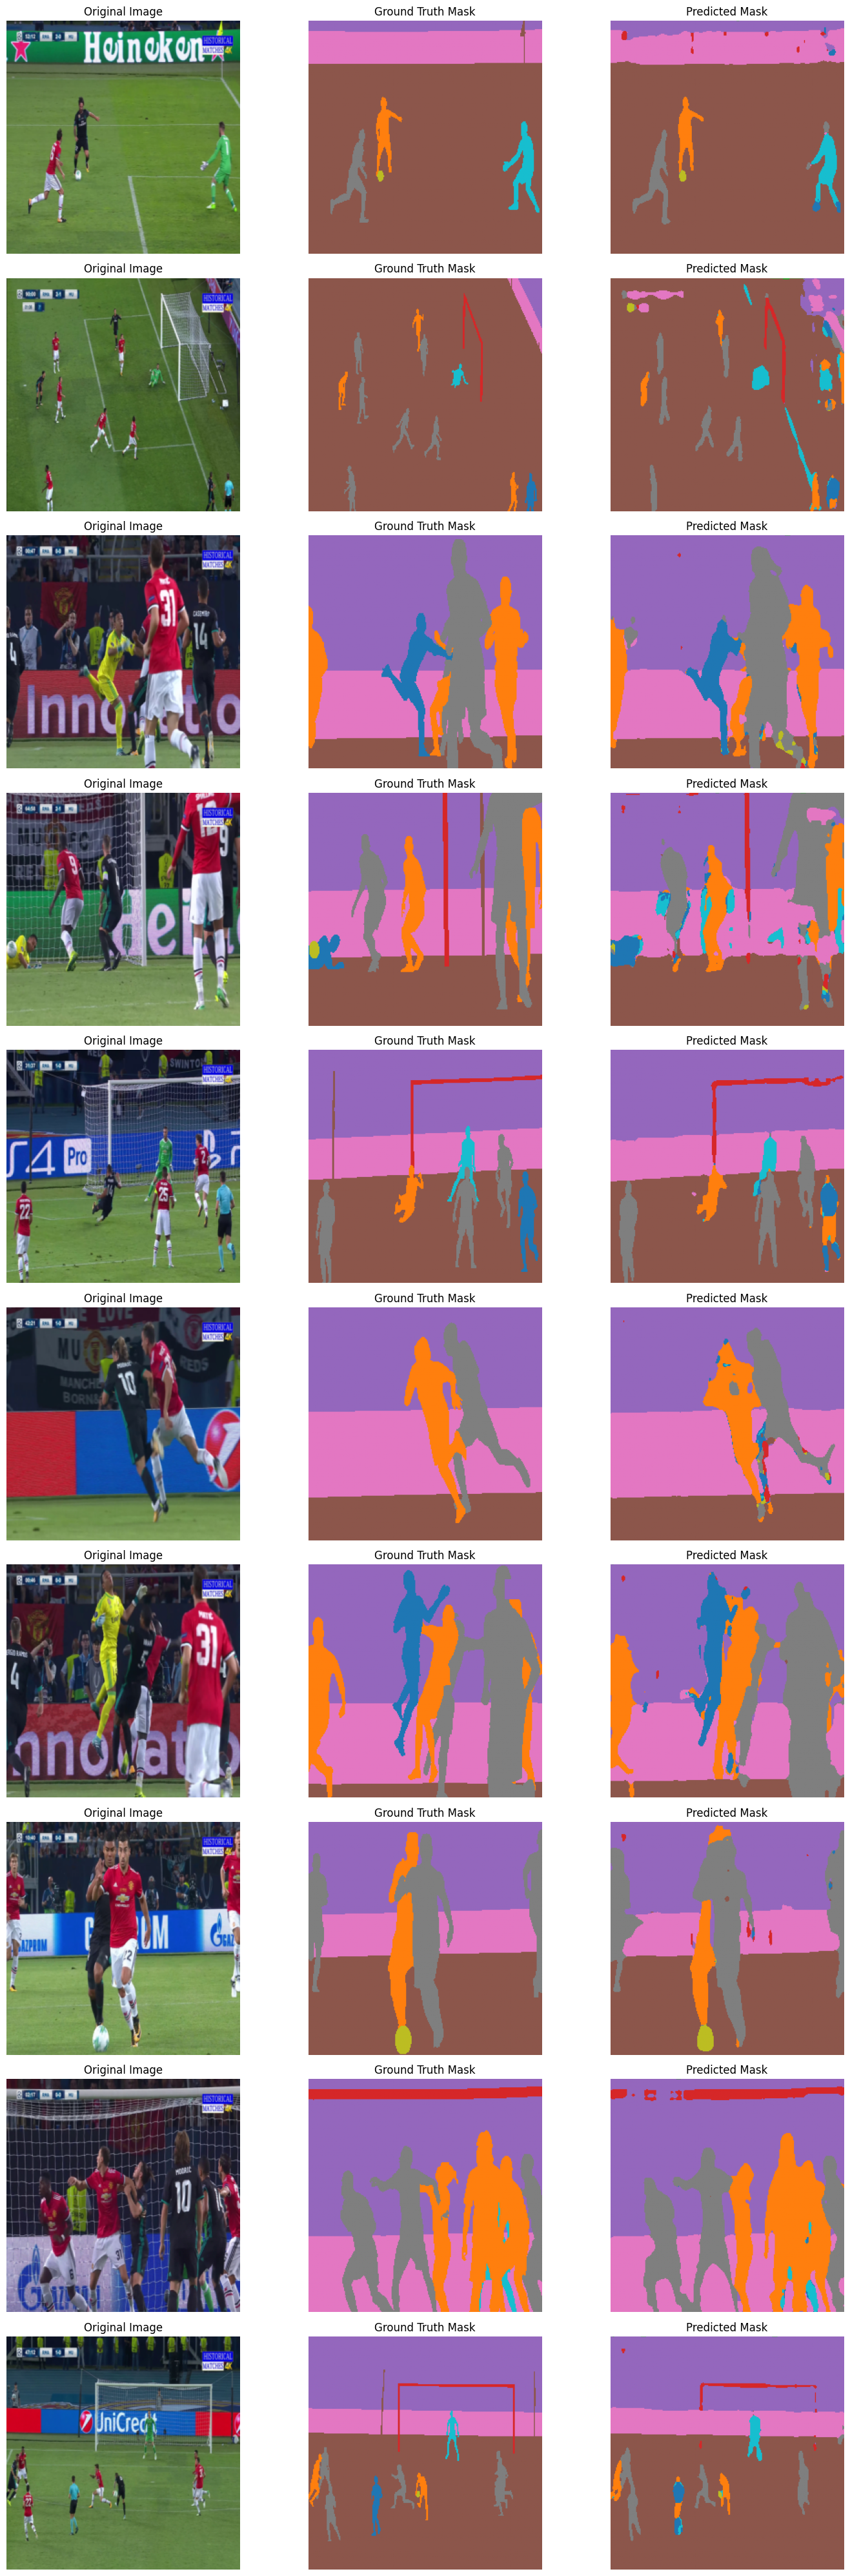

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import torch

# 고정된 컬러맵 설정 (GT & 예측 마스크 동일하게 적용)
fixed_colors = list(mcolors.TABLEAU_COLORS.values())  # "tab10" 컬러 10개 활용
label_colors = {label: fixed_colors[i % len(fixed_colors)] for i, label in enumerate(range(11))}  # 0~10 클래스
cmap_fixed = mcolors.ListedColormap([label_colors[label] for label in sorted(label_colors.keys())])

# 모델 로드 및 예측
backbone_model, _, _ = load_model(backbone_model, "Backbone_UNet", optimizer, scheduler)

with torch.no_grad():
    test_transformed_iter = iter(test_transformed_loader)
    plt.figure(figsize=(15, 40))

    plot_index = 1
    test_transformed_loss = 0
    for images, masks in test_transformed_iter:
        images, masks = images.to(device), masks.to(device)
        outputs = backbone_model(images)
        loss = criterion(outputs, masks)
        test_transformed_loss += loss.item()

        # 예측 마스크 변환 (argmax 적용)
        pred_masks = torch.argmax(torch.softmax(outputs, dim=1), dim=1).cpu().numpy()

        for b in range(images.size(0)):
            # 원본 이미지 출력
            plt.subplot(10, 3, plot_index)
            plt.imshow(images[b].cpu().permute(1, 2, 0).numpy())  # 그대로 출력 가능
            plt.title("Original Image")
            plt.axis("off")
            plot_index += 1

            # Ground Truth Mask 출력 (고정된 컬러맵 적용)
            plt.subplot(10, 3, plot_index)
            plt.imshow(masks[b].cpu().numpy(), cmap=cmap_fixed, vmin=0, vmax=10)
            plt.title("Ground Truth Mask")
            plt.axis("off")
            plot_index += 1

            # Predicted Mask 출력 (고정된 컬러맵 적용)
            plt.subplot(10, 3, plot_index)
            plt.imshow(pred_masks[b], cmap=cmap_fixed, vmin=0, vmax=10)
            plt.title("Predicted Mask")
            plt.axis("off")
            plot_index += 1

            if plot_index > 10 * 3:  # 10개 이미지까지 시각화
                break
        if plot_index > 10 * 3:
            break

    avg_test_transformed_loss = test_transformed_loss / len(test_transformed_loader)
    print(f"Test Loss: {avg_test_transformed_loss}")

    plt.tight_layout()
    plt.show()

Backbone에서는 학습을 조금 더 하면 좋겠다고 생각은 했지만 더 나아질 거라는 확신은 가질 수 없기에 이쯤에서 학습을 마쳤다.

# 4.결과


네가지 모델 전부 결과가 비슷했다. 데이터의 개수가 100개밖에 되지 않기에 생긴 문제라고 생각한다.

비슷한 결과를 캐글에서 찾아볼 수 있었다. (https://www.kaggle.com/code/manuelnkegoum/u-net)

이 글에서도 From Scratch 방식을 사용했는데, validation loss는 0.2 점수대에서 줄지 않았다.

backbone을 이용한 모델도 비슷한 결과를 내는 것을 보았을 때에 아마 0.2정도가 한계이지 않을까 싶다.